# **绘制maintain_only柱状图**

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
def draw_picture(data,tasks,categories,model_name):
    # 设置颜色方案
    colors = sns.color_palette("GnBu", len(tasks))

    # 为每个Rate绘制图表
    for rate in ["10%", "20%", "30%"]:
        df = pd.DataFrame(data[rate], index=categories).T  # 行: tasks, 列: categories
        
        fig, ax = plt.subplots(figsize=(12, 7))
        x = np.arange(len(categories))  # X轴位置
        width = 0.12  # 柱宽
        
        # 绘制每个task的柱子
        for i, task in enumerate(tasks):
            offset = (i - len(tasks)/2) * width + width/2
            bars = ax.bar(x + offset, df.loc[task], width, label=task, color=colors[i])
            #bars = ax.bar(x + offset, 100-df.loc[task], width, label=task, color=colors[i])#由于使用的是错误率，所以
            # 在柱子上方添加数值标签
            # for bar in bars:
            #     height = bar.get_height()
            #     ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            #             f'{height:.1f}%', ha='center', va='bottom', fontsize=8)
        
        # 设置图表属性
        ax.set_xlabel('Category', fontsize=12)
        ax.set_ylabel('Performance (%)', fontsize=12)
        ax.set_title(f'{model_name} - Maintain Only ({rate} Rate)', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(categories)
        ax.set_ylim(0, 105)
        ax.legend(title='Task', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        save_path = f"./analysis_pictures/{model_name}_maintain_only_sentence_rate{rate}.pdf" 
        #save_path = f"./analysis_pictures/{model_name}_maintain_only_words_rate{rate}.pdf" 
        dir = os.path.dirname(save_path )
        os.makedirs(dir, exist_ok=True)
        # 保存为PDF
        plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
        print(f"柱状图已保存到: {save_path}")
        plt.close() 

In [12]:
# 定义数据（根据表格整理）
data_Qwen0_6B = {
    "10%": {
        "High-ATT": [68.4, 41.7, 54.8, 76.7, 70.2],
        "Low-ATT": [10.5, 33.3, 29.0, 37.2, 54.4],
        "Rest": [21.1, 25.0, 64.5, 58.1, 61.4],
        "Sampled-rest": [21.1, 33.3, 41.9, 41.9, 36.8],
        "Sampled-all": [42.1, 8.3, 32.3, 51.2, 31.6],
        "KNN-last": [36.8, 25.0, 35.5, 39.5, 45.6],
        "KNN-pass": [21.1, 33.3, 35.5, 55.8, 47.4]
    },
    "20%": {
        "High-ATT": [63.2, 58.3, 58.1, 72.1, 78.9],
        "Low-ATT": [21.1, 33.3, 35.5, 41.9, 52.6],
        "Rest": [10.5, 16.7, 32.3, 60.5, 57.9],
        "Sampled-rest": [5.3, 25.0, 41.9, 58.1, 45.6],
        "Sampled-all": [26.3, 33.3, 35.5, 39.5, 36.8],
        "KNN-last": [21.1, 33.3, 19.4, 41.9, 56.1],
        "KNN-pass": [26.3, 8.3, 41.9, 44.2, 45.6]
    },
    "30%": {
        "High-ATT": [47.4, 50.0, 61.3, 72.1, 75.4],
        "Low-ATT": [31.6, 8.3, 35.5, 41.9, 64.9],
        "Rest": [21.1, 16.7, 48.4, 55.8, 57.9],
        "Sampled-rest": [15.8, 16.7, 32.3, 30.2, 40.4],
        "Sampled-all": [42.1, 33.3, 41.9, 44.2, 66.7],
        "KNN-last": [5.3, 16.7, 32.3, 37.2, 49.1],
        "KNN-pass": [42.1, 25.0, 45.2, 53.5, 45.6]
    }
}
data_Qwen_4B = {
    "10%": {
        "High-ATT": [80.0, 73.3, 87.0, 76.5, 65.0],
        "Low-ATT": [40.0, 53.3, 34.8, 52.9, 55.0],
        "Rest": [80.0, 86.7, 87.0, 88.2, 95.0],
        "Sampled-rest": [60.0, 26.7, 47.8, 35.3, 40.0],
        "Sampled-all": [66.7, 33.3, 39.1, 47.1, 25.0],
        "KNN-last": [33.3, 60.0, 43.5, 41.2, 40.0],
        "KNN-pass": [53.3, 46.7, 52.2, 41.2, 45.0]
    },
    "20%": {
        "High-ATT": [93.3, 100.0, 100.0, 94.1, 75.0],
        "Low-ATT": [60.0, 33.3, 39.1, 52.9, 80.0],
        "Rest": [66.7, 86.7, 91.3, 94.1, 95.0],
        "Sampled-rest": [46.7, 26.7, 47.8, 35.3, 50.0],
        "Sampled-all": [86.7, 66.7, 65.2, 64.7, 55.0],
        "KNN-last": [33.3, 66.7, 60.9, 52.9, 35.0],
        "KNN-pass": [53.3, 46.7, 47.8, 41.2, 45.0]
    },
    "30%": {
        "High-ATT": [93.3, 100.0, 100.0, 88.2, 90.0],
        "Low-ATT": [33.3, 53.3, 43.5, 47.1, 95.0],
        "Rest": [66.7, 66.7, 69.6, 82.4, 95.0],
        "Sampled-rest": [60.0, 33.3, 43.5, 47.1, 85.0],
        "Sampled-all": [80.0, 66.7, 69.6, 70.6, 80.0],
        "KNN-last": [66.7, 60.0, 56.5, 52.9, 40.0],
        "KNN-pass": [53.3, 40.0, 60.9, 58.8, 75.0]
    }
}
data_Qwen_8B = {
    "10%": {
        "High-ATT": [100.0, 85.7, 84.6, 100.0, 75.0],
        "Low-ATT": [33.3, 28.6, 46.2, 70.6, 81.3],
        "Rest": [54.2, 78.6, 92.3, 88.2, 93.8],
        "Sampled-rest": [45.8, 7.1, 38.5, 35.3, 62.5],
        "Sampled-all": [50.0, 7.1, 23.1, 23.5, 68.8],
        "KNN-last": [45.8, 21.4, 46.2, 47.1, 50.0],
        "KNN-pass": [33.3, 21.4, 38.5, 35.3, 56.3]
    },
    "20%": {
        "High-ATT": [100.0, 85.7, 92.3, 76.5, 93.8],
        "Low-ATT": [29.2, 35.7, 38.5, 47.1, 87.5],
        "Rest": [45.8, 78.6, 53.8, 94.1, 93.8],
        "Sampled-rest": [37.5, 42.9, 61.5, 47.1, 62.5],
        "Sampled-all": [75.0, 35.7, 53.8, 58.8, 62.5],
        "KNN-last": [50.0, 42.9, 61.5, 64.7, 68.8],
        "KNN-pass": [45.8, 28.6, 46.2, 52.9, 62.5]
    },
    "30%": {
        "High-ATT": [100.0, 85.7, 100.0, 94.1, 87.5],
        "Low-ATT": [16.7, 35.7, 53.8, 64.7, 93.8],
        "Rest": [41.7, 78.6, 84.6, 88.2, 93.8],
        "Sampled-rest": [16.7, 28.6, 76.9, 52.9, 87.5],
        "Sampled-all": [75.0, 50.0, 76.9, 70.6, 62.5],
        "KNN-last": [58.3, 57.1, 61.5, 64.7, 68.8],
        "KNN-pass": [37.5, 64.3, 69.2, 64.7, 75.0]
    }
}

categories = ["Facts", "Law", "Biology", "CS", "Math"]
tasks = ["High-ATT", "Low-ATT", "Rest", "Sampled-rest", "Sampled-all", "KNN-last", "KNN-pass"]
draw_picture(data=data_Qwen0_6B,tasks=tasks,categories=categories,model_name="Qwen3-0.6B")
draw_picture(data=data_Qwen_4B,tasks=tasks,categories=categories,model_name="Qwen3-4B")
draw_picture(data=data_Qwen_8B,tasks=tasks,categories=categories,model_name="Qwen3-8B")


柱状图已保存到: ./analysis_pictures/Qwen3-0.6B_maintain_only_sentence_rate10%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-0.6B_maintain_only_sentence_rate20%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-0.6B_maintain_only_sentence_rate30%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-4B_maintain_only_sentence_rate10%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-4B_maintain_only_sentence_rate20%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-4B_maintain_only_sentence_rate30%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-8B_maintain_only_sentence_rate10%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-8B_maintain_only_sentence_rate20%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-8B_maintain_only_sentence_rate30%.pdf


In [13]:
categories = ["Facts", "Law", "Biology", "CS", "Math"]
tasks = ["High-ATT", "Low-ATT", "Random-w","Random-wo","Selected"]
data_Qwen0_6B= {
    "10%": {
        "High-ATT": [100.0, 91.7, 93.5, 83.7, 86.0],
        "Low-ATT": [15.8, 25.0, 48.4, 51.2, 61.4],
        "Random-w": [36.8, 41.7, 58.1, 55.8, 59.6],
        "Random-wo": [36.8, 41.7, 51.6, 53.5, 54.4],
        "Selected": [52.6, 58.3, 51.6, 60.5, 68.4]
    },
    "20%": {
        "High-ATT": [94.7, 91.7, 93.5, 81.4, 96.5],
        "Low-ATT": [15.8, 41.7, 35.5, 55.8, 73.7],
        "Random-w": [73.7, 50.0, 71.0, 76.7, 73.7],
        "Random-wo": [31.6, 33.3, 41.9, 55.8, 38.6],
        "Selected": [52.6, 58.3, 51.6, 60.5, 68.4]
    },
    "30%": {
        "High-ATT": [94.7, 83.3, 96.8, 86.0, 96.5],
        "Low-ATT": [10.5, 41.7, 38.7, 72.1, 61.4],
        "Random-w": [84.2, 75.0, 83.9, 79.1, 78.9],
        "Random-wo": [31.6, 8.3, 45.2, 44.2, 50.9],
        "Selected": [52.6, 58.3, 51.6, 60.5, 68.4]
    }
}
data_Qwen_4B = {
    "10%": {
        "High-ATT": [100.0, 100.0, 100.0, 100.0, 95.0],
        "Low-ATT": [33.3, 60.0, 64.3, 47.1, 85.0],
        "Random-w": [80.0, 66.7, 85.7, 76.5, 75.0],
        "Random-wo": [93.3, 80.0, 71.4, 57.1, 70.0],
        "Selected": [100.0, 93.3, 69.6, 64.7, 60.0]
    },
    "20%": {
        "High-ATT": [100.0, 93.3, 100.0, 100.0, 95.0],
        "Low-ATT": [40.0, 60.0, 64.3, 52.9, 90.0],
        "Random-w": [93.3, 80.0, 71.4, 88.2, 100.0],
        "Random-wo": [86.7, 93.3, 92.9, 64.3, 70.0],
        "Selected": [100.0, 93.3, 69.6, 64.7, 60.0]
    },
    "30%": {
        "High-ATT": [100.0, 100.0, 100.0, 94.1, 100.0],
        "Low-ATT": [66.7, 66.7, 64.3, 94.1, 95.0],
        "Random-w": [93.3, 93.3, 71.4, 88.2, 100.0],
        "Random-wo": [80.0, 73.3, 92.9, 75.0, 85.0],
        "Selected": [100.0, 93.3, 69.6, 64.7, 60.0]
    }
}
data_Qwen_8B = {
    "10%": {
        "High-ATT": [95.8, 100.0, 92.3, 100.0, 100.0],
        "Low-ATT": [45.8, 57.1, 46.2, 64.7, 93.8],
        "Random-w": [58.3, 64.3, 84.6, 64.7, 100.0],
        "Random-wo": [62.5, 57.1, 84.6, 64.7, 75.0],
        "Selected": [100.0, 71.4, 100.0, 82.4, 68.8]
    },
    "20%": {
        "High-ATT": [100.0, 100.0, 100.0, 94.1, 100.0],
        "Low-ATT": [41.7, 64.3, 69.2, 70.6, 100.0],
        "Random-w": [83.3, 71.4, 92.3, 88.2, 100.0],
        "Random-wo": [70.8, 71.4, 84.6, 82.4, 87.5],
        "Selected": [100.0, 71.4, 100.0, 82.4, 68.8]
    },
    "30%": {
        "High-ATT": [100.0, 100.0, 100.0, 100.0, 100.0],
        "Low-ATT": [50.0, 57.1, 76.9, 76.5, 100.0],
        "Random-w": [91.7, 85.7, 84.6, 82.4, 93.8],
        "Random-wo": [87.5, 78.6, 84.6, 82.4, 87.5],
        "Selected": [100.0, 71.4, 100.0, 82.4, 68.8]
    }
}
draw_picture(data=data_Qwen0_6B,tasks=tasks,categories=categories,model_name="Qwen3-0.6B")
draw_picture(data=data_Qwen_4B,tasks=tasks,categories=categories,model_name="Qwen3-4B")
draw_picture(data=data_Qwen_8B,tasks=tasks,categories=categories,model_name="Qwen3-8B")

柱状图已保存到: ./analysis_pictures/Qwen3-0.6B_maintain_only_sentence_rate10%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-0.6B_maintain_only_sentence_rate20%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-0.6B_maintain_only_sentence_rate30%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-4B_maintain_only_sentence_rate10%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-4B_maintain_only_sentence_rate20%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-4B_maintain_only_sentence_rate30%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-8B_maintain_only_sentence_rate10%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-8B_maintain_only_sentence_rate20%.pdf
柱状图已保存到: ./analysis_pictures/Qwen3-8B_maintain_only_sentence_rate30%.pdf


# **绘制TSNE降维图**

In [14]:
import os
import torch
import matplotlib.pyplot as plt
def draw_projection(data_2d,labels,count,top_k_percentage,output_path,method):
    title=f"topk{top_k_percentage}_{method}_Visualization{count}"
    scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=labels, cmap='viridis')
    plt.colorbar(scatter)
    plt.title(title)
    plt.xlabel(f'{method} Component 1')
    plt.ylabel(f'{method} Component 2')
    os.makedirs(output_path, exist_ok=True)
    plt.savefig(output_path+title+".pdf", format='pdf', bbox_inches='tight')
    plt.close()

In [15]:
data_name={
    0:'gpqa',
    1:'mmlu',
    2:'ComVE',
    3:'esnli',
    4:'mmlu_redux',
   # 4:'ecqa',
    }[4]
    
sub_set={
    0:'global_facts',
    1:'high_school_mathematics',
    2:'college_mathematics',
    3:'high_school_computer_science',
    4:'college_computer_science',
    5:'high_school_biology',
    6:'college_biology',
    7:'professional_law'
}[0]
    
model_name={
    0:'DeepSeek-R1-Distill-Qwen-7B',
    1:'DeepSeek-R1-Distill-Llama-8B',
    2:'Qwen3-8B',
    3:'Qwen3-4B',
    4:'Qwen3-0.6B'
}[4]
root='.'
method={
0:'tsne',
1:'umap'
}[1]
rate=1
topk_percentage_list=[0.1,0.2,0.3]
top_k_percentage=0.3
#for top_k_percentage in topk_percentage_list:
labels_file=f'{root}/{method}_data/intermediate_result/{data_name}/{model_name}/{sub_set}_rate{rate}_all_labels_topk{top_k_percentage}.pth'
last_file=f'{root}/{method}_data/intermediate_result/{data_name}/{model_name}/{sub_set}_rate{rate}_all_{method}_2d_last_topk{top_k_percentage}.pth'
pass_file=f'{root}/{method}_data/intermediate_result/{data_name}/{model_name}/{sub_set}_rate{rate}_all_{method}_2d_pass_topk{top_k_percentage}.pth'
labels=torch.load(labels_file,weights_only=False)
data_last=torch.load(last_file,weights_only=False)
data_pass=torch.load(pass_file,weights_only=False)
KNN_path=f'{root}/final_results/maintain_KNN_{method}/filter/'
mask_path='unmask/'
KNN_indices_last=f"{model_name}-{data_name}-{sub_set}-indices-last-top_percentage{top_k_percentage}.pth"
KNN_indices_pass=f"{model_name}-{data_name}-{sub_set}-indices-pass-top_percentage{top_k_percentage}.pth"
indices_list_last=torch.load(KNN_path+mask_path+KNN_indices_last,weights_only=False)
indices_list_pass=torch.load(KNN_path+mask_path+KNN_indices_pass,weights_only=False)

In [16]:
KNN_all_labels_last=[]
KNN_all_labels_pass=[]
for i in range(len(indices_list_last)):
    labels_KNN_last=[0]*len(labels[i])
    labels_KNN_pass=[0]*len(labels[i])
    for j in indices_list_last[i]:
        labels_KNN_last[j]=1
    for j in indices_list_pass[i]:
        labels_KNN_pass[j]=1
    KNN_all_labels_last.append(labels_KNN_last)
    KNN_all_labels_pass.append(labels_KNN_pass)

In [17]:
idx=1
last_flag_list=[True,False]
knn_flag_list=[True,False]
for knn_flag in knn_flag_list:
    for last_flag in last_flag_list:
        if knn_flag:
            if last_flag:
                projection_2d=data_last[idx]
                projection_labels=KNN_all_labels_last[idx]
                output_path=f"./{method}_pictures/{data_name}/{sub_set}/knn_last/{model_name}/"
            else:
                projection_2d=data_pass[idx]
                projection_labels=KNN_all_labels_pass[idx]
                output_path=f"./{method}_pictures/{data_name}/{sub_set}/knn_pass/{model_name}/"
        else:
            projection_labels=labels[idx]
            if last_flag:
                projection_2d=data_last[idx]
                output_path=f"./{method}_pictures/{data_name}/{sub_set}/topk_last/{model_name}/"
            else:
                projection_2d=data_pass[idx]
                output_path=f"./{method}_pictures/{data_name}/{sub_set}/topk_pass/{model_name}/"
        draw_projection(projection_2d,projection_labels,idx,top_k_percentage,output_path,method)

# **绘制metric箱线图和柱状图**

In [18]:
import json

In [19]:
def get_score(metric_data):
    score_tuple_list=[]
    score_sum=0
    for idx in range(len(metric_data)):
        label=0
        if metric_data[idx]['model_answer']==metric_data[idx]['truth']:
            label=1
        score_sum+=metric_data[idx]['score']*100
        score_tuple_list.append((metric_data[idx]['score']*100,label))
    average_score=score_sum/len(metric_data)
    return average_score,score_tuple_list
    

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
def draw_metric_score(data, model_names, tasks):
    """
    绘制不同模型在各任务上性能的柱状图
    
    参数:
    data: 二维列表，形状为 [len(model_names)][len(tasks)]
    model_names: 模型名称列表
    tasks: 任务名称列表
    """
    # 设置颜色方案 - 使用不同的调色板，每个任务一个颜色
    colors = sns.color_palette("GnBu", len(tasks))
    
    # 设置中文字体（如果需要）
    # plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
    # plt.rcParams['axes.unicode_minus'] = False
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # X轴位置（模型位置）
    x = np.arange(len(model_names))
    width = 0.12  # 柱宽
    
    # 转换为DataFrame以便操作
    df = pd.DataFrame(data, index=model_names, columns=tasks)
    
    # 绘制每个task的柱子
    for i, task in enumerate(tasks):
        # 计算每个柱子的偏移量，使其居中显示
        offset = (i - len(tasks)/2) * width + width/2
        bars = ax.bar(x + offset, df[task], width, label=task, color=colors[i],
                     edgecolor='white', linewidth=1.2)
        
        # 在柱子上方添加数值标签
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                   f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='medium')
    
    # 设置图表属性
    ax.set_xlabel('Model', fontsize=13, fontweight='bold')
    ax.set_ylabel('Faithfulness Score', fontsize=13, fontweight='bold')
    ax.set_title('Model Faithfulness Comparison Across Different Tasks', 
                fontsize=16, fontweight='bold', pad=20)
    
    # 设置X轴刻度
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontsize=12, fontweight='medium')
    
    # 设置Y轴范围（留一些空间给数值标签）
    y_max = np.max(data) * 1.15
    ax.set_ylim(0, 100)
    
    # 添加网格线
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    
    # 添加图例
    ax.legend(title='Tasks', fontsize=11, title_fontsize=12, 
             bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
    
    # 添加边框
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
    
    # 调整布局
    plt.tight_layout()
    save_path = f"./metric_pictures/average_score/" 
    save_file="average_score_across_models_tasks(rouge_L).pdf" 
    os.makedirs(save_path, exist_ok=True)
    # 保存为PDF
    plt.savefig(save_path+save_file, format='pdf', dpi=300, bbox_inches='tight')
    print(f"柱状图已保存到: {save_path+save_file}")
    plt.close() 

In [21]:
def draw_boxplot(data, tasks,model_name):
    # 提取数据
    task_data = []
    for task_list in data:
        values = [item[0] for item in task_list]
        task_data.append(values)
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # 设置颜色方案
    colors = sns.color_palette("Set2", len(tasks))
    
    # 创建箱线图（半透明）
    boxplot = ax.boxplot(task_data, patch_artist=True, 
                         widths=0.3, showmeans=False,showfliers=False,
                        #  meanprops={'marker': 'D', 'markerfacecolor': 'white', 
                        #            'markeredgecolor': 'red', 'markersize': 8},
                         medianprops={'color': 'black','linewidth': 1})
    
    # 为每个箱线图设置颜色
    for patch, color in zip(boxplot['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.3)
        patch.set_edgecolor(color)
        patch.set_linewidth(2)
    
    # # 创建小提琴图
    # positions = range(1, len(tasks) + 1)
    # vp = ax.violinplot(task_data, positions=positions, 
    #                    widths=0.8, showmeans=False, showmedians=False)
    
    # # 为每个小提琴图设置颜色
    # for i, pc in enumerate(vp['bodies']):
    #     pc.set_facecolor(colors[i])
    #     pc.set_edgecolor(colors[i])
    #     pc.set_alpha(0.4)
    #     pc.set_linewidth(1)
    
    # 设置图表属性
    #ax.set_xlabel('Task', fontsize=10, fontweight='bold')
    ax.set_ylabel('Score', fontsize=10)
    
    title_text = f'{model_name} score boxplot'
    ax.set_title(title_text, fontsize=10, fontweight='bold')
    
    # 设置X轴刻度
    ax.set_xticks(range(1, len(tasks) + 1))
    ax.set_xticklabels(tasks, fontsize=10, fontweight='medium')
    
    # 计算并设置Y轴范围
    all_values = [value for sublist in task_data for value in sublist]
    #y_padding = (max(all_values) - min(all_values)) * 0.1
    #ax.set_ylim(min(all_values) - y_padding, max(all_values) + y_padding)
    ax.set_ylim(0, 100)
    # 添加网格线
    ax.grid(axis='y', linestyle='--', alpha=0.2, zorder=0)
    
    # 添加边框
    for spine in ax.spines.values():
        spine.set_linewidth(1)
    
    # 添加图例
    from matplotlib.lines import Line2D
    legend_elements = [
        # Line2D([0], [0], color='red', marker='D', linestyle='None', 
        #        markersize=8, label='Mean'),
        Line2D([0], [0], color='black', linewidth=1, label='Median'),
        #Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='Whisker')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=10)
    
    # # 添加数据点（抖动散点图）
    # for i, values in enumerate(task_data, 1):
    #     # 添加一些抖动避免点重叠
    #     x_jittered = np.random.normal(i, 0.05, len(values))
    #     ax.scatter(x_jittered, values, alpha=0.5, s=30, 
    #               color=colors[i-1], edgecolor='white', linewidth=0.5, zorder=3)
    
    plt.tight_layout()
    save_path = f"./metric_pictures/boxplot/" 
    save_file=f"{model_name}_score_boxplot(rouge_L).pdf" 
    os.makedirs(save_path, exist_ok=True)
    # 保存为PDF
    plt.savefig(save_path+save_file, format='pdf', dpi=300, bbox_inches='tight')
    print(f"箱线图已保存到: {save_path+save_file}")
    plt.close()

In [23]:
data_name={
0:'gpqa',
1:'mmlu',
2:'ComVE',
3:'esnli',
4:'mmlu_redux',
# 4:'ecqa',
}[4]
input_path='./final_results/metric/origin/'
model_names=['Qwen3-0.6B','Qwen3-4B', 'Qwen3-8B']
tasks = ["Facts", "Law", "Biology", "CS", "Math"]
all_average_score=[]
for model_name_idx in [4,3,2]:
    all_score_tuple_list=[]
    average_score_list=[]
    for sub_set_idx in range(5):
        sub_set={
            0:'global_facts',
            1:['high_school_mathematics','college_mathematics'],
            2:['high_school_computer_science','college_computer_science'],
            3:['high_school_biology','college_biology'],
            4:'professional_law'
        }[sub_set_idx]
        model_name={
            0:'DeepSeek-R1-Distill-Qwen-7B',
            1:'DeepSeek-R1-Distill-Llama-8B',
            2:'Qwen3-8B',
            3:'Qwen3-4B',
            4:'Qwen3-0.6B'
        }[model_name_idx]
        metric_data=[]
        if isinstance(sub_set,list):
            for str in sub_set:
                input_file=f'{model_name}-{data_name}-{str}-metric_record(rouge_L).json'
                with open(input_path+input_file) as f:
                    data=json.load(f)
                metric_data=metric_data+data
        else:
            input_file=f'{model_name}-{data_name}-{sub_set}-metric_record(rouge_L).json'
            with open(input_path+input_file) as f:
                data=json.load(f)
            metric_data=metric_data+data
        average_score,score_tuple_list=get_score(metric_data)
        all_score_tuple_list.append(score_tuple_list)
        average_score_list.append(average_score)
    draw_boxplot(all_score_tuple_list,tasks,model_name)
    all_average_score.append(average_score_list)

FileNotFoundError: [Errno 2] No such file or directory: './final_results/metric/origin/Qwen3-0.6B-mmlu_redux-high_school_mathematics-metric_record(rouge_L).json'

ValueError: zero-size array to reduction operation maximum which has no identity

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

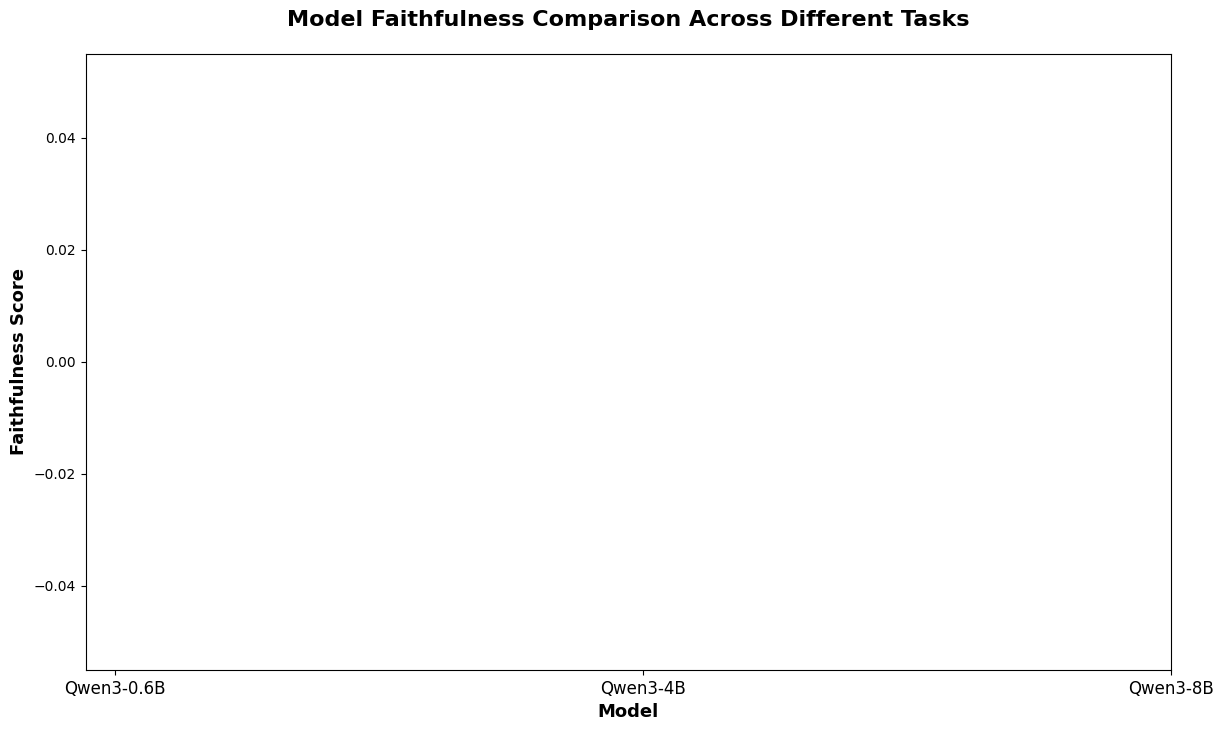

In [24]:
model_names=['Qwen3-0.6B','Qwen3-4B', 'Qwen3-8B']
tasks = ["Facts", "Law", "Biology", "CS", "Math"]
draw_metric_score(all_average_score,model_names,tasks)

# **select正确性与score的关系可视化**

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import os
def drarw_relation(scores_list,save_file):
    sorted_data = sorted(scores_list, key=lambda x: x[0], reverse=True)

    # 2. 分离数据用于绘图
    scores = [item[0] for item in sorted_data]
    labels = [item[1] for item in sorted_data]

    # 3. 创建x轴的位置
    x_positions = np.arange(len(scores))

    # 4. 根据label设置颜色
    colors = ['blue' if label == 0 else 'orange' for label in labels]

    # 5. 绘制柱状图
    plt.figure(figsize=(12, 6))
    bars = plt.bar(x_positions, scores, color=colors, edgecolor='black')

    # 6. 添加标签和标题
    plt.xlabel('id', fontsize=12)
    plt.ylabel('score', fontsize=12)
    plt.title('score and correct', fontsize=14)

    # 7. 添加分数值在柱状图顶部
    # for i, score in enumerate(scores):
    #     plt.text(i, score + 0.5, f'{score:.1f}', ha='center', va='bottom', fontsize=9)

    # 8. 创建图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='blue', edgecolor='black', label='wrong'),
        Patch(facecolor='orange', edgecolor='black', label='correct')
    ]
    plt.legend(handles=legend_elements)

    # 9. 设置x轴刻度
    plt.xticks(x_positions, x_positions + 1)  # 从1开始计数

    # 10. 调整布局
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    save_path = f"./metric_pictures/relation/" 
    os.makedirs(save_path, exist_ok=True)
    # 保存为PDF
    plt.savefig(save_path+save_file, format='pdf', dpi=300, bbox_inches='tight')
    print(f"图已保存到: {save_path+save_file}")
    plt.close()

In [26]:
import json
data_name={
0:'gpqa',
1:'mmlu',
2:'ComVE',
3:'esnli',
4:'mmlu_redux',
# 4:'ecqa',
}[4]
input_path='./final_results/maintain_only_sentences/model_select/'
model_names=['Qwen3-0.6B','Qwen3-4B', 'Qwen3-8B']
tasks = ["Facts", "Law", "Biology", "CS", "Math"]
all_average_score=[]
for model_name_idx in [4,3,2]:
    all_score_tuple_list=[]
    average_score_list=[]
    for sub_set_idx in range(5):
        sub_set={
            0:'global_facts',
            1:['high_school_mathematics','college_mathematics'],
            2:['high_school_computer_science','college_computer_science'],
            3:['high_school_biology','college_biology'],
            4:'professional_law'
        }[sub_set_idx]
        task_name={
            0:'fact',
            1:'math',
            2:'cs',
            3:'biology',
            4:'law'
        }[sub_set_idx]
        model_name={
            0:'DeepSeek-R1-Distill-Qwen-7B',
            1:'DeepSeek-R1-Distill-Llama-8B',
            2:'Qwen3-8B',
            3:'Qwen3-4B',
            4:'Qwen3-0.6B'
        }[model_name_idx]
        maintain_select_data=[]
        if isinstance(sub_set,list):
            for str in sub_set:
                input_file=f'{model_name}-{data_name}-{str}-model_select.json'
                with open(input_path+input_file) as f:
                    data=json.load(f)
                maintain_select_data=maintain_select_data+data
        else:
            input_file=f'{model_name}-{data_name}-{sub_set}-model_select.json'
            with open(input_path+input_file) as f:
                data=json.load(f)
            maintain_select_data=maintain_select_data+data
        scores_list=[]
        for sample in maintain_select_data:
            if sample['prediction']==sample['previous_prediction']:
                label=1
            else:
                label=0
            scores_list.append((sample['score'],label))
        save_file=f'{model_name}-{data_name}-{task_name}-relation.pdf'
        drarw_relation(scores_list,save_file)

图已保存到: ./metric_pictures/relation/Qwen3-0.6B-mmlu_redux-fact-relation.pdf


FileNotFoundError: [Errno 2] No such file or directory: './final_results/maintain_only_sentences/model_select/Qwen3-0.6B-mmlu_redux-high_school_mathematics-model_select.json'